In [1]:
from os.path import join
import numpy as np
import torch
from scipy.stats import norm
import matplotlib.pyplot as plt

from GPR_MLIP.evaluation import separate_into_bins, calc_bin_dist, set_ticks

RESULT_ROOT_PATH = join('..', 'results', 'uncertainty_error_calculation')

In [2]:
def plot_selected_dists(result_path, bin_size, selection, y_ticks, min_samples=50):    
    uncertainties = torch.load(join(result_path, f'uncertainties'), weights_only=False)
    errors = torch.load(join(result_path, f'errors'), weights_only=False)

    positions_, bin_values_, counts = separate_into_bins(
        torch.sqrt(uncertainties['GPR model'])*1000,
        errors['GPR model']*1000,
        bin_size=bin_size
    )

    enough_samples = (counts > min_samples)
    
    counts = counts[enough_samples]
    positions_ = positions_[enough_samples]
    bin_values_ = [bin_values_[i] for i, enough in enumerate(enough_samples) if enough]

    selection = selection + [len(bin_values_) - 1]

    fig, axes = plt.subplots(1, len(selection), figsize=(len(selection)*5, 5))
    for i, bin_idx in enumerate(selection):
        
        axes[i] = plot_bin_dist(axes[i], bin_values_[bin_idx], positions_[bin_idx])

        title = f'Bin {bin_idx+1}'
        if i + 1 == len(selection):
            title = f'Bin {bin_idx+1} (last bin)'
        
        axes[i].set_title(title, fontsize=14)

        if i == 0:
            axes[i].set_ylabel('Count', fontsize=14)
            axes[i].legend(fontsize=14, loc='upper right');
            set_ticks(axes[i], y_ticks=y_ticks, grid=False)
        else:
            set_ticks(axes[i], y_ticks=y_ticks, grid=False, show_y_ticks=False)
        
        axes[i].text(
            0.05, 0.65,  
            f'n samples = {int(counts[bin_idx])}', 
            transform=axes[i].transAxes,
            fontsize=14,
            verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none') 
        )


def plot_bin_dist(ax, values, std, num_bins=100):
    max_absolute_value = max(abs(np.array(values)))
    bin_size = (2*max_absolute_value) / (num_bins - 1)
    
    bins = np.arange(-max_absolute_value, max_absolute_value + bin_size, bin_size)
    x = np.linspace(-max_absolute_value, max_absolute_value, 1000)

    pdf = norm.pdf(x, 0, std)

    ax.hist(values, bins=bins, alpha=0.5, density=True, label='True errors');
    ax.plot(x, pdf, 'r-', lw=2, label='Predicted error \ndistribution')
    ax.set_xlabel('Error in meV', fontsize=14)
    return ax

# Aspirin

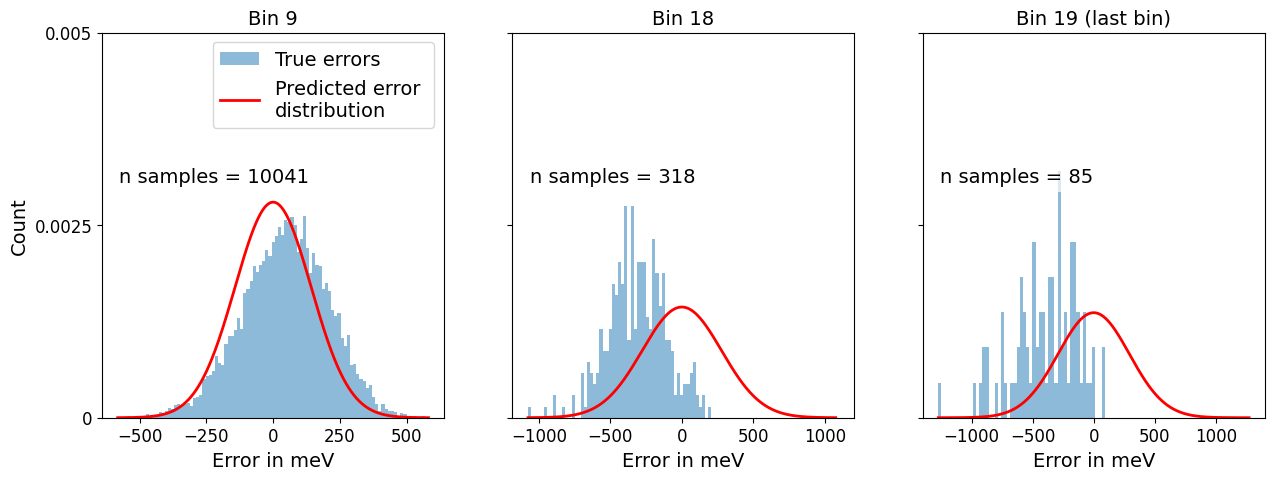

In [3]:
plot_selected_dists(
    result_path = join(RESULT_ROOT_PATH, 'rmd17', 'aspirin', 'GPR_coulomb_rbf'),
    bin_size = 15, 
    selection = [8, 17],
    y_ticks = [0, 0.0025, 0.005]
)

# O-HBDI

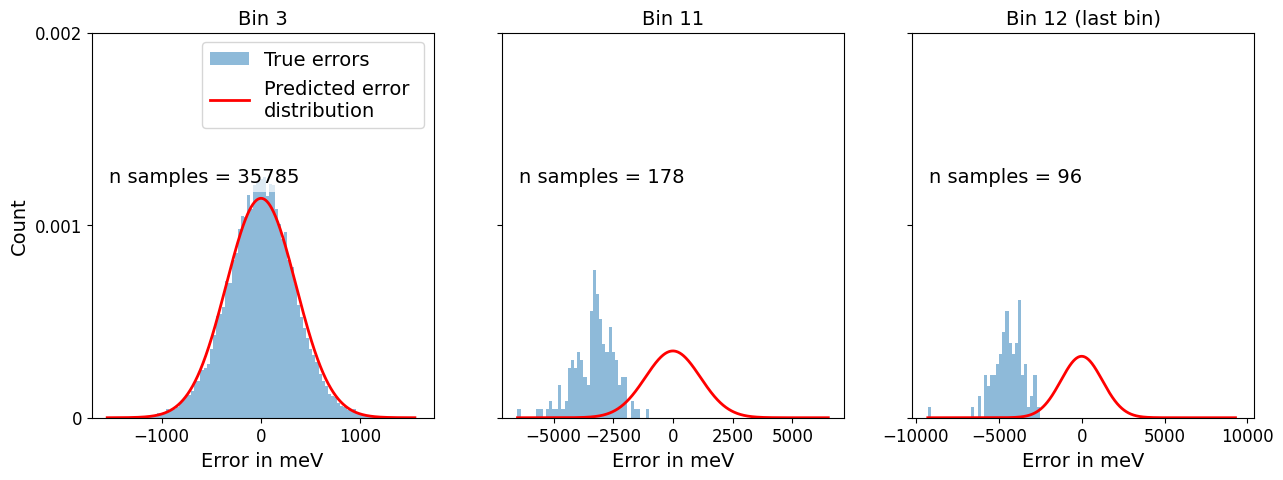

In [4]:
plot_selected_dists(
    result_path = join(RESULT_ROOT_PATH, 'ws22', 'ws22_o-hbdi', 'GPR_coulomb_rbf'),
    bin_size = 100, 
    selection = [2, 10],
    y_ticks = [0, 0.001, 0.002]
)